# Target construction

This notebook runs the target construction module and performs quick sanity checks:
- class balance
- forward return separation by class
- expected NaNs near the end of each ticker series

## Basic Setup

### Imports and Paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_FEAT_PATH = "../data/processed/financial_database_features.parquet"
OUT_MODEL_PATH = "../data/processed/financial_database_model_ready.parquet"

Shape: (27650, 49)


### Load Dataset

In [9]:
df = pd.read_parquet(IN_FEAT_PATH)
df["date"] = pd.to_datetime(df["date"])
print("Shape:", df.shape)

Shape: (27650, 49)


## Target Construction

### Build the Target

The target is built by applying the target construction module to the engineered dataset. This produces a forward-return based label consistent with the modeling horizon.

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.preprocessing.target_construction import TargetConfig, construct_target, make_model_ready

cfg = TargetConfig(
    bot_q=0.30,
    top_q=0.70,
    min_points_cs=5,
)

df_t = construct_target(df, cfg)
df_model = make_model_ready(df_t, cfg)

print("With target:", df_t.shape)
print("Model-ready:", df_model.shape)


With target: (27650, 53)
Model-ready: (27020, 53)


## Target Sanity Check

### NaN ratios

Check the proportion of missing targets. NaNs are expected near the dataset tail because forward returns cannot be computed beyond the available date range.

In [13]:
print("Percentage of missing target values:", df_t["target"].isna().mean() * 100)
print("First date with missing target values:", df_t[df_t["target"].isna()]["date"].min())

Percentage of missing target values: 2.278481012658228
First date with missing target values: 2025-10-01 00:00:00


### Class balance

Inspect class balance to ensure no extreme class imbalance is introduced by the target definition.

In [5]:
df_model["target"].value_counts(normalize=True).sort_index()

target
-1    0.3
 0    0.4
 1    0.3
Name: proportion, dtype: float64

### Coherence

Validate coherence by confirming that higher target classes correspond to higher forward returns on average.

<Figure size 640x480 with 0 Axes>

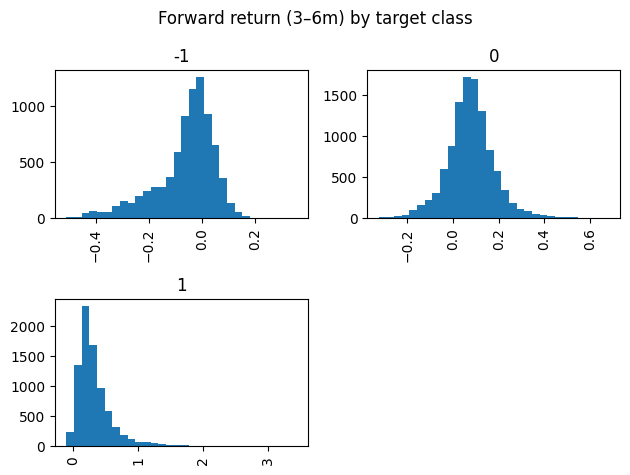

,count,mean,std,min,10%,50%,90%,max
target,,,,,,,,
-1,8106.0,-0.060872,0.112634,-0.511265,-0.225328,-0.035077,0.054070,0.354357
0,10808.0,0.077942,0.105705,-0.324468,-0.042247,0.075409,0.200020,0.680031
1,8106.0,0.330909,0.291410,-0.104325,0.083479,0.259230,0.645452,3.430250


In [8]:
tmp = df_model.copy()

plt.figure()
tmp["fwd_ret_3_6m"].hist(by=tmp["target"], bins=30, grid=False)
plt.suptitle("Forward return (3–6m) by target class")
plt.tight_layout()
plt.show()

tmp.groupby("target")["fwd_ret_3_6m"].describe(percentiles=[.1, .5, .9])

These checks jointly confirm that the target is well-defined, balanced enough for modeling, and aligned with forward-return behavior.

## Save New Dataset

In [7]:
df_model.to_parquet(OUT_MODEL_PATH, index=False)
print("Saved:", OUT_MODEL_PATH)

Saved: ../data/processed/financial_database_model_ready.parquet
